# Do Discounts Influence Consumer Spending Behavior?

This project aims to analyze consumer spending behavior using a publicly available dataset. The analysis includes exploratory data analysis (EDA) and hypothesis testing to understand the effects of demographic factors and product categories on purchase amounts. Since direct discount information is not available, proxy variables are used to capture potential discount effects.

## Exploratory Data Analysis (EDA)
This section explores the dataset to understand its structure, key variables, and general patterns in consumer behavior before conducting further analysis.

In [5]:
import pandas as pd

df = pd.read_csv("Black Friday Dataset.csv")
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


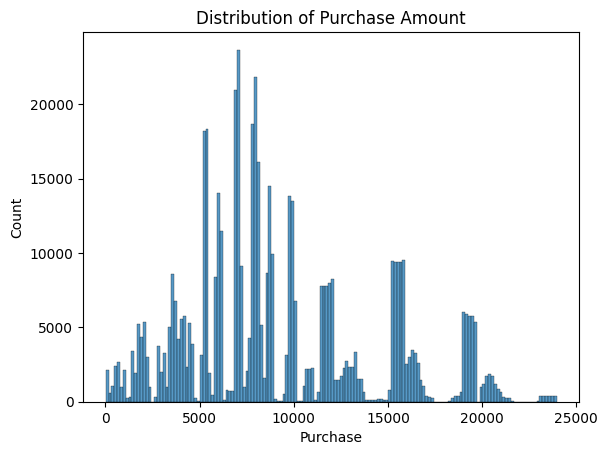

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Purchase"])
plt.title("Distribution of Purchase Amount")
plt.show()

**Distribution of Purchase Amounts**

The distribution of purchase amounts shows that most transactions are concentrated in the lower to mid range, while fewer transactions occur at very high spending levels. This indicates that most customers tend to make moderate purchases.

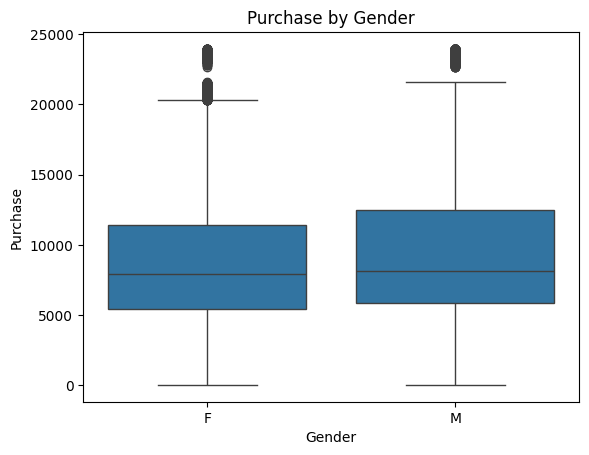

In [7]:
sns.boxplot(x="Gender", y="Purchase", data=df)
plt.title("Purchase by Gender")
plt.show()

**Analysis of Purchase Amounts by Gender**

The boxplot comparing purchase amounts by gender indicates that male customers have a slightly higher median purchase value than female customers. However, there is a substantial overlap between the distributions, suggesting that the difference is relatively small.

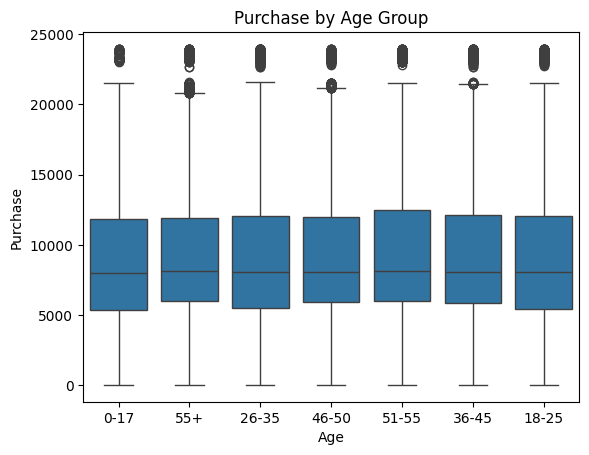

In [8]:
sns.boxplot(x="Age", y="Purchase", data=df)
plt.title("Purchase by Age Group")
plt.show()

**Analysis of Purchase Amounts by Age Group**

The analysis of purchase amounts across different age groups indicates that some age groups appear to have slightly higher spending levels. However, the differences between groups are not very large, suggesting that age may have a limited effect on consumer spending behavior. Overall, age does not appear to be a primary determinant of consumer spending.

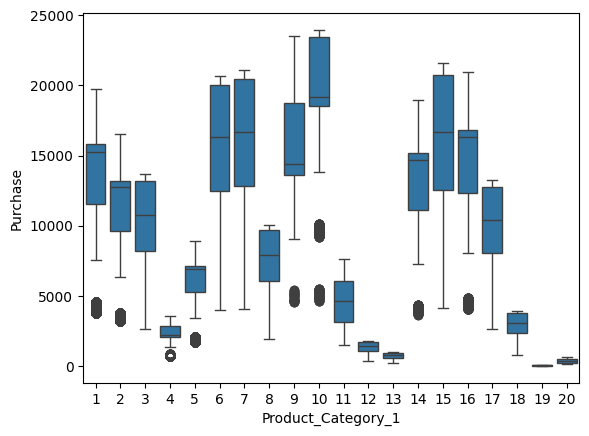

In [9]:
sns.boxplot(x="Product_Category_1", y="Purchase", data=df)
plt.show()

**Analysis of Purchase Amounts by Product Category**

There is a clear variation in purchase amounts across product categories. Some categories are associated with significantly higher spending levels, suggesting that product type may influence how much customers spend.

**Use of Proxy Variables**

Since discount information is not directly available, product categories are used as a proxy to capture differences in pricing and potential discount effects. This variation suggests that product category may serve as a meaningful proxy for pricing differences. However, this proxy may not perfectly represent actual discount levels, which is a limitation of the analysis.

## Hypothesis Testing

In [10]:
from scipy.stats import ttest_ind

male = df[df["Gender"]=="M"]["Purchase"]
female = df[df["Gender"]=="F"]["Purchase"]

ttest_ind(male, female)

TtestResult(statistic=np.float64(44.837957934353966), pvalue=np.float64(0.0), df=np.float64(550066.0))

**Hypothesis Test: Gender and Purchase Amount**

A t-test was conducted to compare purchase amounts between male and female customers. The results indicate that there is a statistically significant difference between the two groups (p < 0.05), suggesting that gender may influence consumer spending behavior. The extremely small p-value (close to 0) provides strong evidence against the null hypothesis.

In [13]:
from scipy.stats import f_oneway

group1 = df[df["Product_Category_1"]==1]["Purchase"]
group2 = df[df["Product_Category_1"]==2]["Purchase"]
group3 = df[df["Product_Category_1"]==3]["Purchase"]

f_oneway(group1, group2, group3)

F_onewayResult(statistic=np.float64(8850.42690783338), pvalue=np.float64(0.0))

**Hypothesis Test: Product Category and Purchase Amount**

An ANOVA test was conducted to examine whether purchase amounts differ across product categories. The results show that there are statistically significant differences between categories (p < 0.05), indicating that product category may influence consumer spending behavior. Therefore, the null hypothesis is rejected.

### Conclusion
The analysis shows that consumer spending behavior is influenced by factors such as gender and product category. While gender differences are statistically significant, their effect appears to be relatively small compared to product categories.
In contrast, product categories show a much stronger impact on purchase amounts, indicating that the type of product plays a key role in determining how much customers spend.
Since direct discount data is not available, product categories were used as proxy variables to approximate discount effects. However, this approach has limitations and may not fully capture actual discount levels.
Overall, the findings suggest that pricing differences across product categories are likely to influence consumer spending behavior. Future research using detailed pricing or discount data could provide deeper insights and more accurate conclusions.